In [9]:
#load all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score



In [10]:
# Load the data
X_train=pd.read_csv("../output/x_train.csv")
X_test=pd.read_csv("../output/x_test.csv")
y_train=pd.read_csv("../output/y_train.csv").squeeze()
y_test=pd.read_csv("../output/y_test.csv").squeeze()

In [11]:

# Apply Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.neural_network import MLPClassifier

# Initialize the Neural Network
# hidden_layer_sizes=(10, 10) means 2 layers with 10 neurons each
neural_network_mlp = MLPClassifier(hidden_layer_sizes=(10, 10), 
                    activation='relu', 
                    solver='adam', 
                    max_iter=1000, 
                    random_state=42)

# Train the model using scaled data
neural_network_mlp.fit(X_train_scaled, y_train)

# Make predictions
y_predicted_neural_network_mlp = neural_network_mlp.predict(X_test_scaled)
# Generate probabilities for ROC-AUC
y_probabilities_for_ROC_AUC = neural_network_mlp.predict_proba(X_test_scaled)
    

# Calculate the metrics
accuracy_of_the_neural_net_model = accuracy_score(y_test, y_predicted_neural_network_mlp)
precision_of_the_neural_net_model = precision_score(y_test, y_predicted_neural_network_mlp, average='weighted')
recall_of_the_neural_net_model = recall_score(y_test, y_predicted_neural_network_mlp, average='weighted')
f1_score_of_the_neural_net_model = f1_score(y_test, y_predicted_neural_network_mlp, average='weighted')
roc_auc_score_of_the_neural_net_model = roc_auc_score(y_test, y_probabilities_for_ROC_AUC, multi_class='ovr', average='weighted')


# Print the results
print(f"Accuracy:  {accuracy_of_the_neural_net_model:.4f}")
print(f"Precision: {precision_of_the_neural_net_model:.4f}")
print(f"Recall:    {recall_of_the_neural_net_model:.4f}")
print(f"F1-score:  {f1_score_of_the_neural_net_model:.4f}")
print(f"ROC-AUC:  {roc_auc_score_of_the_neural_net_model:.4f}")

Accuracy:  0.5809
Precision: 0.5578
Recall:    0.5809
F1-score:  0.5679
ROC-AUC:  0.7496


C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


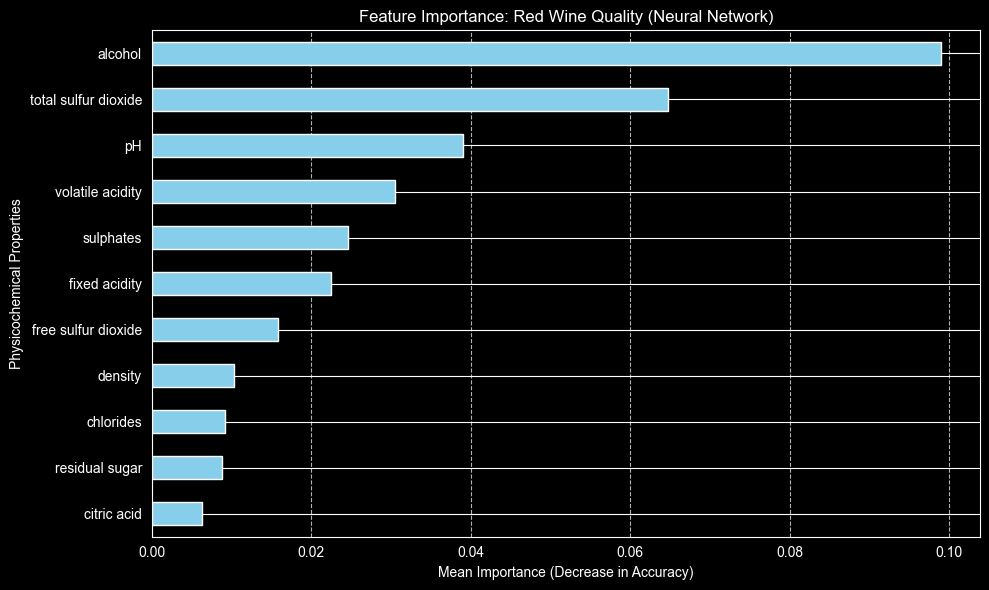

In [13]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Calculate Permutation Importance for your Neural Network
# This measures how much the model's accuracy drops when a feature is shuffled
result = permutation_importance(
    neural_network_mlp, 
    X_test_scaled, 
    y_test, 
    n_repeats=10, 
    random_state=42
)

# Organize the data for plotting
# X.columns contains: fixed acidity, volatile acidity, citric acid, pH, alcohol, etc.
feature_importance = pd.Series(
    result.importances_mean, 
    index=X_train.columns
).sort_values(ascending=True)

# Create the Visualization
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='skyblue')

plt.title("Feature Importance: Red Wine Quality (Neural Network)")
plt.xlabel("Mean Importance (Decrease in Accuracy)")
plt.ylabel("Physicochemical Properties")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
# make csv file for evaluation
neural_net_result=pd.DataFrame({
    "Model":["Neural Net"],
    "Accuracy":[accuracy_of_the_neural_net_model],
    "Precision":[precision_of_the_neural_net_model],
    "Recall":[recall_of_the_neural_net_model],
    "F1-Score":[f1_score_of_the_neural_net_model],
    "ROC-AUC":[roc_auc_score_of_the_neural_net_model]
})
neural_net_result.to_csv("../output/neural_net_result.csv",index=False)